In [ ]:
"""
PROPÓSITO:
Este bloque consolida y documenta todas las librerías necesarias para ejecutar
el ciclo completo de ciencia de datos: desde la ingesta segura y limpieza,
hasta el modelado predictivo dual (Clasificación y Regresión), su validación
robusta y visualización avanzada.

ORGANIZACIÓN POR BLOQUES LÓGICOS:

1. Sistema, Red y Seguridad:
   - os, hashlib, requests: Gestión de datasets remotos y validación de integridad (SHA-256).

2. Computación Vectorial y Estructuras de Datos:
   - pandas (pd), numpy (np): Motores de manipulación tabular y álgebra lineal.

3. Visualización Estadística:
   - matplotlib.pyplot (plt), seaborn (sns): Análisis exploratorio y renderizado de gráficos.
   - ConfusionMatrixDisplay, roc_curve, precision_recall_curve: Herramientas para la
     evaluación visual del rendimiento de modelos de clasificación.

4. Scikit-Learn (Arquitectura de Pipelines y Preprocesamiento):
   - Pipeline, ColumnTransformer: Encapsulamiento del flujo de datos para evitar Data Leakage.
   - Transformadores (StandardScaler, OneHotEncoder, etc.): Preparación matemática de variables.

5. Scikit-Learn (Modelos Supervisados - Requisito de Rúbrica):
   - Clasificación: LogisticRegression, DecisionTreeClassifier, SVC.
   - Regresión: LinearRegression, DecisionTreeRegressor.

6. Scikit-Learn (Validación, Optimización y Métricas):
   - train_test_split, StratifiedKFold, cross_validate: Estrategias de segmentación
     y validación cruzada para asegurar la estabilidad del modelo.
   - GridSearchCV: Búsqueda exhaustiva de hiperparámetros.
   - metrics: Evaluadores robustos (Accuracy, F1, ROC-AUC, etc.) para dictaminar
     la efectividad del modelo.

7. Reproducibilidad:
   - np.random.seed: Fijación de la semilla (SEED = 42) para garantizar la trazabilidad
     y permitir auditorías exactas de los resultados ante la comisión evaluadora.
"""

# 1. SISTEMA, RED Y SEGURIDAD
import os
import hashlib
import requests

# 2. COMPUTACIÓN VECTORIAL Y MANIPULACIÓN DE DATOS
import pandas as pd
import numpy as np

# 3. VISUALIZACIÓN ESTADÍSTICA AVANZADA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

# 4. SCIKIT-LEARN: ARQUITECTURA DE PIPELINES Y PREPROCESAMIENTO
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer


# 5. SCIKIT-LEARN: ALGORITMOS DE MACHINE LEARNING SUPERVISADO
# 5.1 Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# 5.2 Regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor


# 6. SCIKIT-LEARN: ENTRENAMIENTO, OPTIMIZACIÓN Y EVALUACIÓN
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)



# Configuración de reproducibilidad
SEED = 42
np.random.seed(SEED)

In [ ]:
def auditar_integridad_y_esquema_url(url_archivo):
    """
    Realiza una auditoría de un archivo remoto descargándolo en streaming para
    verificar su integridad criptográfica y validar su esquema estructural básico.

    UTILIDAD Y PROPÓSITO DE LA INTEGRIDAD (HASH SHA-256):

    1. Trazabilidad y MLOps: El hash actúa como una "huella digital" inmutable del dataset.
       Permite registrar con qué versión exacta de los datos se entrenó un modelo. Si el
       archivo en GitHub es actualizado o sobreescrito en el futuro, el hash cambiará,
       alertando al equipo sobre la modificación y garantizando la reproducibilidad.

    2. Prevención de Corrupción de Datos: Al descargar archivos de internet, existen
       riesgos de micro-cortes de red o descargas incompletas. El cálculo del hash asegura
       que los bytes procesados coinciden exactamente con la totalidad del archivo esperado,
       evitando que datos corruptos envenenen el pipeline de Machine Learning.


    UTILIDAD Y PROPÓSITO DE LA VALIDACIÓN DE ESQUEMA:

    1. Principio "Fail-Fast" (Falla Rápido): Al leer solo la primera fila del CSV (nrows=0),
       el sistema verifica la existencia de las variables críticas sin tener que cargar
       gigabytes de datos a la RAM. Si falta una columna, el proceso se detiene de
       inmediato, ahorrando tiempo de cómputo y costos de procesamiento en la nube.

    Parámetros:
    url_archivo (str): La URL directa (raw) del archivo CSV a auditar.

    Retorna:
    str: El hash SHA-256 del archivo si las validaciones son exitosas, o None si ocurre un error.
    """
    print("Iniciando Auditoría de Integridad y Esquema desde URL")

    sha256_hash = hashlib.sha256()

    # 1. VALIDACIÓN DE INTEGRIDAD (HASH) DESDE URL
    try:
        # Hacemos una petición GET a la URL.
        # stream=True permite leer el archivo por partes sin cargarlo todo en RAM
        respuesta = requests.get(url_archivo, stream=True)
        respuesta.raise_for_status() # Lanza un error si la descarga falla (ej. error 404)

        # Leemos el archivo en bloques de 4KB (4096 bytes)
        for byte_block in respuesta.iter_content(chunk_size=4096):
            if byte_block: # Filtramos los "keep-alive" vacíos
                sha256_hash.update(byte_block)

        checksum = sha256_hash.hexdigest()

        print("INTEGRIDAD: Checksum SHA-256 calculado correctamente.")
        print(f"   -> Archivo: {url_archivo}")
        print(f"   -> Hash: {checksum}")

    except requests.exceptions.RequestException as e:
        print(f"ERROR: No se pudo descargar el archivo de la URL. Detalle: {e}")
        return None

    # 2. VALIDACIÓN DE ESQUEMA (COLUMNAS) DESDE URL
    try:
        # Pandas puede leer URLs directamente. Mantenemos nrows=0 para mayor velocidad.
        df_esquema = pd.read_csv(url_archivo, nrows=0)

        columnas_encontradas = df_esquema.columns.tolist()
        columnas_criticas = ['id_cliente', 'abandono', 'ingreso_mensual', 'deuda_total']

        columnas_faltantes = [col for col in columnas_criticas if col not in columnas_encontradas]

        if not columnas_faltantes:
            print("ESQUEMA: Todas las variables críticas están presentes en el origen.")
        else:
            print(f"ADVERTENCIA: Faltan las siguientes columnas críticas: {columnas_faltantes}")

    except Exception as e:
        print(f"ERROR al validar el esquema con Pandas: {e}")
        return None

    return checksum

# --- CÓMO USARLO ---
url = 'https://raw.githubusercontent.com/agustilin/Ev1_grupo_5/refs/heads/main/data/dataset_clientes.csv'

# Le pasamos la variable 'url'
hash_dataset = auditar_integridad_y_esquema_url(url)

Iniciando Auditoría de Integridad y Esquema desde URL
INTEGRIDAD: Checksum SHA-256 calculado correctamente.
   -> Archivo: https://raw.githubusercontent.com/agustilin/Ev1_grupo_5/refs/heads/main/data/dataset_clientes.csv
   -> Hash: ac8ed445faf148dac481236a2c045716ef0a6d6f54f6f8fbab6d8c5efc7ecfac
ESQUEMA: Todas las variables críticas están presentes en el origen.


# Fase 1: Auditoria y analisis exploratorio de Datos (EDA)

In [ ]:
df = pd.read_csv(url)
df.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


Analisis de los datos
Lo primero que podemos hacer es conocer en esquemas generales la informacion y que tipo de datos guarda la tabla
Podemos identificar

Nombre de las columnas
Columnas con valores nulos (ingreso_mensual, gasto_mensual, score_crediticio)
Tipo de dato que almacena cada variable

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

Mediante la función describe() (y excluyendo la variable id_cliente y codigo_postal por carecer de utilidad analítica) generaremos las métricas estadísticas principales. Este paso es fundamental para evaluar la calidad de los datos, identificar la presencia de valores atípicos (outliers) y determinar la estrategia de limpieza adecuada

In [ ]:
df.drop(columns=['id_cliente', 'codigo_postal']).describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,abandono
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,0.396814
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,0.489249
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,0.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,0.000000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,1.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,1.000000


Ingreso mensual, gasto mensual y deuda total guarda valores negativos, clara identificacion de outliers

Repetimos el proceso anterior para las variables categoricas

In [ ]:
df.describe(include="object")

,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro
count,20400,20400,20400,20400,20400,20400,20400,20400
unique,2000,3,3,3,3,3,3,7
top,2022-04-09,Otro,Sur,Casado,Bajo,Estandar,App,Miercoles
freq,21,6997,6812,6828,6886,6878,6894,3000


Analizamos el numero de columans vacias

In [ ]:
df.isna().sum()

,0
id_cliente,0
fecha_registro,0
edad,0
genero,0
region,0
estado_civil,0
ingreso_mensual,1021
gasto_mensual,1025
deuda_total,0
score_crediticio,1021


Deteccion y visualizacion de duplicados mediante el ID, tal como señaló el caso

In [ ]:
df.duplicated().sum()

np.int64(400)

In [ ]:
# keep=False permite mostrar todas las apariciones del registro duplicado
filas_duplicadas = df[df.duplicated(keep=False)]

# Mostramos el resultado
filas_duplicadas['id_cliente']

,id_cliente
177,178
215,216
326,327
353,354
415,416
...,...
20395,4925
20396,1627
20397,13007
20398,17724


In [ ]:
"""
FASE EDA / LIMPIEZA ESTRUCTURAL: TRATAMIENTO DE DUPLICADOS

PROPÓSITO:
Garantizar la unicidad de los registros en el dataset maestro antes de
realizar cualquier separación de variables (X e y) o partición de datos
(train_test_split).

JUSTIFICACIÓN TÉCNICA:
En la arquitectura de Scikit-Learn, los Pipelines están diseñados para transformar
columnas, no para eliminar filas. Si se intentan eliminar registros duplicados
de la matriz de características (X) internamente en un Pipeline, se generará
un desfase de dimensiones con el vector objetivo (y), provocando el colapso
del modelo durante el entrenamiento (ValueError: inconsistent numbers of samples).
Ejecutar esta limpieza directamente sobre el DataFrame original ('df') previene
este error crítico y preserva la simetría matemática obligatoria entre X e y.

IMPLICANCIA DE NEGOCIO:
Asegura que el modelo no aprenda patrones sesgados causados por la repetición
artificial de ciertos perfiles y garantiza que las proyecciones de retención
estén basadas en clientes 100% únicos.
"""

print("--- ELIMINACIÓN DE REGISTROS DUPLICADOS ---")
print(f"Dimensiones originales del dataset: {df.shape}")

# Eliminamos duplicados basados en el identificador único ('id_cliente')
# El parámetro inplace=True modifica el DataFrame original liberando memoria RAM
# keep='first' asegura que nos quedemos con el primer registro que apareció
df.drop_duplicates(subset=['id_cliente'], keep='first', inplace=True)

print(f"\nDimensiones después de limpiar duplicados: {df.shape}")
print("Limpieza exitosa: Ahora cada fila representa a un cliente único.")

--- ELIMINACIÓN DE REGISTROS DUPLICADOS ---
Dimensiones originales del dataset: (20400, 22)

Dimensiones después de limpiar duplicados: (20000, 22)
Limpieza exitosa: Ahora cada fila representa a un cliente único.


In [ ]:
# keep=False permite mostrar todas las apariciones del registro duplicado
filas_duplicadas = df[df.duplicated(keep=False)]

# Mostramos el resultado
filas_duplicadas['id_cliente']

,id_cliente


In [ ]:
"""
RESETEO DE ÍNDICE (PREVENCIÓN DE CORRUPCIÓN DE DATOS)

JUSTIFICACIÓN TÉCNICA:
Al eliminar registros (duplicados o anómalos), Pandas preserva las etiquetas
del índice original, generando discontinuidades numéricas ("huecos").
Si estos huecos no se reparan, los algoritmos de partición de Scikit-Learn
(como StratifiedKFold o train_test_split) pueden fallar por errores de
referencia (KeyError) al intentar acceder a posiciones de memoria inexistentes.

Con esta instrucción, reconstruimos un índice secuencial limpio (0 a N-1),
garantizando la compatibilidad absoluta con las operaciones de álgebra lineal
del Pipeline y protegiendo la integridad de la Validación Cruzada.
"""

# Reseteamos el índice para tapar los "huecos" dejados por los duplicados
df.reset_index(drop=True, inplace=True)

In [ ]:
target = "abandono"

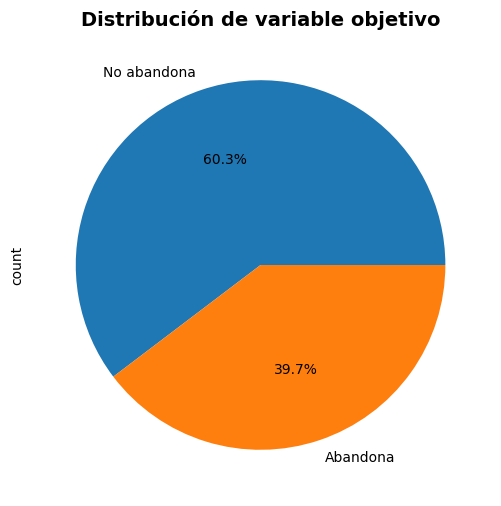

In [ ]:
"""
PROPÓSITO:
Visualizar la distribución porcentual de las clases dentro de la variable objetivo
(Churn/Abandono) mediante un gráfico circular (Pie chart).

JUSTIFICACIÓN TÉCNICA Y DE NEGOCIO:
Este paso analítico es fundamental para detectar la presencia de desbalance de clases.
Evidenciar gráficamente que la proporción de clientes que "Abandonan" es significativamente
menor a los que "No abandonan" justifica decisiones arquitectónicas posteriores, como el
uso del parámetro 'stratify=y' en la división de datos y la elección del F1-Score
(sobre el Accuracy) como métrica principal de evaluación de los modelos predictivos.
"""

df[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['No abandona', 'Abandona'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()

In [ ]:
"""
PROPÓSITO:
Identificar y aislar registros con valores físicamente imposibles o fuera de
los límites lógicos del negocio dentro del DataFrame 'df'.

JUSTIFICACIÓN LÓGICA:
Se aplica una máscara booleana evaluando que las métricas monetarias, de tiempo
y de cantidad no contengan valores negativos. Adicionalmente, se valida que la
'hora_registro' se mantenga estrictamente en el formato de 24 horas (0 a 23).
"""

# Detectar inconsistencias en el dataset 'df'
inconsistentes = df[
    (df["edad"] < 0) |
    (df["ingreso_mensual"] < 0) |
    (df["gasto_mensual"] < 0) |
    (df["deuda_total"] < 0) |
    (df["score_crediticio"] < 0) |
    (df["antiguedad_meses"] < 0) |
    (df["frecuencia_compra"] < 0) |
    (df["ultima_compra_dias"] < 0) |
    (df["num_productos"] < 0) |
    (df["hora_registro"] < 0) |
    (df["hora_registro"] > 23)
]

print(f"Registros inconsistentes encontrados: {len(inconsistentes)}")
display(inconsistentes)

Registros inconsistentes encontrados: 213


,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
45,46,2022-11-24,54,Femenino,Norte,Divorciado,5.473621e+05,273201.310188,-8.694468e+03,473.446896,...,191,Bajo,Premium,3,0,Tienda,Lunes,22,4291,1
70,71,2020-08-14,61,Masculino,Sur,Casado,7.716767e+05,243134.658673,-1.408061e+05,806.103110,...,88,Bajo,Basico,5,0,Tienda,Martes,12,9585,0
183,184,2021-11-26,51,Femenino,Sur,Divorciado,1.302779e+06,453967.270846,-3.485321e+05,670.121767,...,42,Bajo,Estandar,1,0,Tienda,Lunes,1,6337,0
333,334,2020-01-10,23,Femenino,Sur,Soltero,1.164257e+06,387980.429461,-4.506767e+04,610.847787,...,276,Bajo,Premium,2,1,Web,Domingo,23,6918,1
386,387,2019-02-10,52,Masculino,Norte,Soltero,2.314476e+05,318878.873987,-4.868549e+05,512.609207,...,96,Medio,Basico,5,0,Web,Viernes,4,2315,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19630,19631,2019-11-05,34,Masculino,Centro,Casado,3.290083e+05,258410.053513,-3.858681e+05,658.299572,...,23,Medio,Premium,1,1,Web,Miercoles,3,7091,1
19697,19698,2020-12-29,47,Otro,Norte,Soltero,6.012687e+05,-81238.343577,2.400200e+06,697.927105,...,4,Medio,Basico,5,1,Web,Martes,22,1164,0
19780,19781,2022-01-22,68,Otro,Sur,Casado,-2.175158e+04,700310.319186,1.028881e+06,765.565292,...,182,Bajo,Estandar,1,1,Web,Lunes,0,2513,1
19899,19900,2019-07-20,49,Otro,Sur,Divorciado,1.010069e+06,-109632.105470,2.363982e+06,665.326586,...,137,Alto,Estandar,3,1,Tienda,Sabado,11,6363,0


In [ ]:
"""
PROPÓSITO:
Aplicar una estrategia de 'rescate no destructivo' transformando a valores
absolutos (.abs()) los registros numéricos que, por error de digitación o
extracción del sistema, se hayan ingresado con signo negativo en el DataFrame 'df'.

JUSTIFICACIÓN TÉCNICA Y DE NEGOCIO:
Al aplicar .abs() en lugar de eliminar estas filas, conservamos la magnitud
real del comportamiento del cliente (ej. la deuda real, la edad o el ingreso).
Esto protege el volumen de datos de entrenamiento y evita que valores negativos
erróneos distorsionen el límite inferior del MinMaxScaler durante el preprocesamiento.
"""

# Lista completa adaptada a tu dataset con variables que deben ser estrictamente positivas
columns_to_correct = [
    "edad",
    "ingreso_mensual",
    "gasto_mensual",
    "deuda_total",
    "score_crediticio",
    "antiguedad_meses",
    "frecuencia_compra",
    "ultima_compra_dias",
    "num_productos"
]

# Corrección sistemática de signos in-place sobre el DataFrame global
for col in columns_to_correct:
    if col in df.columns:
        df[col] = df[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas cuantitativas de 'df'.")

Valores negativos corregidos a valores absolutos en las columnas cuantitativas de 'df'.


In [ ]:
"""
PROPÓSITO:
Verificar que la estrategia de rescate de datos haya sido exitosa y confirmar
que el DataFrame 'df' se encuentre libre de anomalías matemáticas o lógicas
antes de avanzar al análisis exploratorio y modelado.
"""

# Detectar inconsistencias nuevamente después de la corrección de signos
inconsistentes_corregido = df[
    (df["edad"] < 0) |
    (df["ingreso_mensual"] < 0) |
    (df["gasto_mensual"] < 0) |
    (df["deuda_total"] < 0) |
    (df["score_crediticio"] < 0) |
    (df["antiguedad_meses"] < 0) |
    (df["frecuencia_compra"] < 0) |
    (df["ultima_compra_dias"] < 0) |
    (df["num_productos"] < 0) |
    (df["hora_registro"] < 0) |
    (df["hora_registro"] > 23)
]

print("Registros inconsistentes encontrados después de la corrección:")
display(inconsistentes_corregido)

# Validación automatizada del estado de los datos
if inconsistentes_corregido.empty:
    print("No se encontraron valores negativos ni horas inválidas después de la corrección.")
else:
    print(f"Aún existen {len(inconsistentes_corregido)} inconsistencias.")

Registros inconsistentes encontrados después de la corrección:


,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono


No se encontraron valores negativos ni horas inválidas después de la corrección.


In [ ]:
# 1. Definimos la lista de variables numéricas puras (excluyendo tiempo e identificadores)
numeric_features = [
    "edad",
    "ingreso_mensual",
    "gasto_mensual",
    "deuda_total",
    "score_crediticio",
    "antiguedad_meses",
    "frecuencia_compra",
    "ultima_compra_dias",
    "num_productos"
]

In [ ]:
# Definimos las variables categóricas nominales (sin orden jerárquico)
categorical_nominal_features = [
    'genero',
    'region',
    'estado_civil',
    'canal_registro',
    'dia_semana_registro',
    'tiene_tarjeta_credito'  # Funciona como nominal (Sí/No) para el aprendizaje
]

In [ ]:
categorical_ordinal_features = [
    'uso_app',          # Alto, Medio, Bajo
    'tipo_plan'        # Básico, Estándar, Premium
]

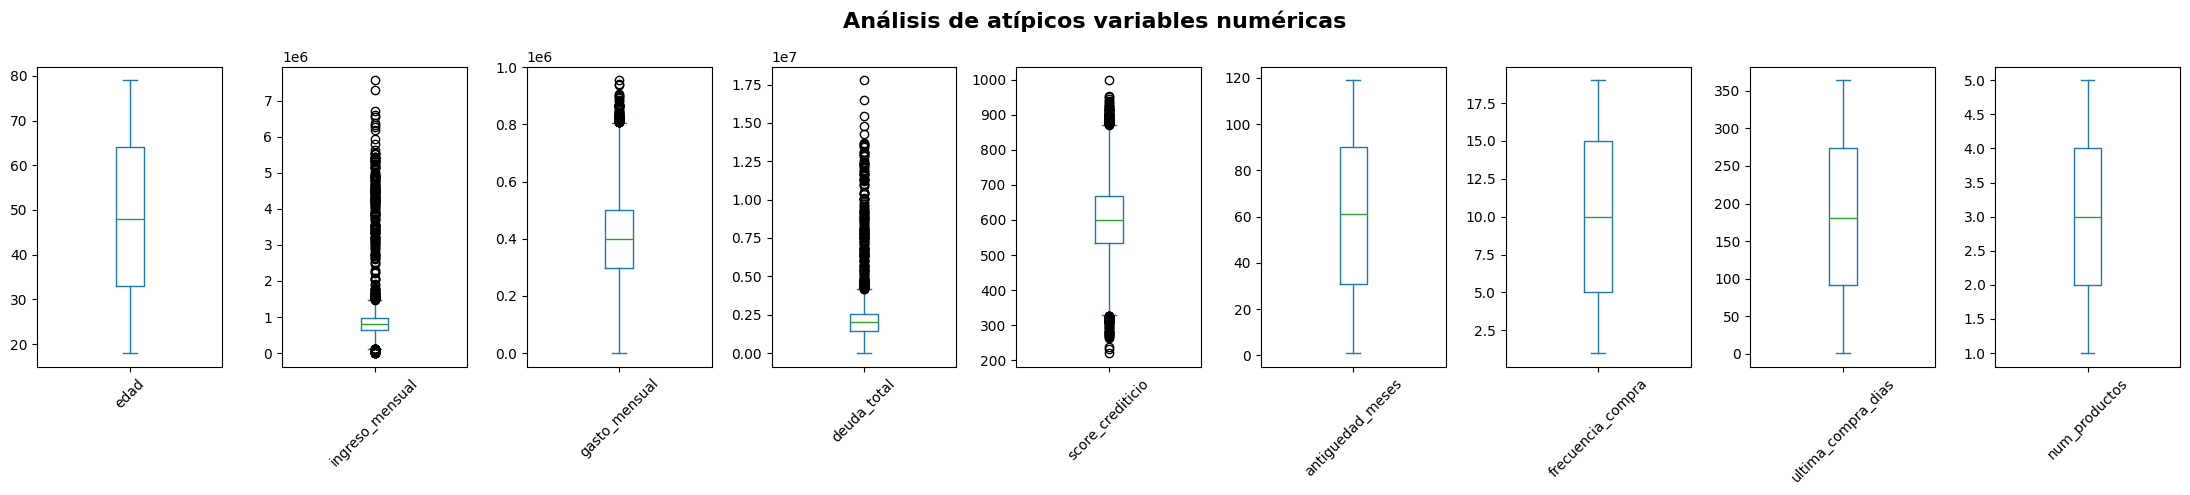

In [ ]:
def visualizar_atipicos_numericos(df, revision):
    """
    Esta función filtra las variables numéricas relevantes según la metadata del negocio
    (excluyendo identificadores, variables espaciales, de tiempo o binarias) y genera un
    lienzo con subgráficos de caja. Esto permite diagnosticar la calidad de los datos
    antes de aplicar métodos de corrección de outliers (como Winsorizer).

    Parámetros:
        df (pd.DataFrame): El conjunto de datos base que contiene la información de los clientes.
        revision (list): Lista con los nombres de las columnas a visualizar.

    Retorna:
        None: Renderiza la visualización de matplotlib directamente.
    """
    # Ajustamos el ancho del gráfico dinámicamente según la cantidad de variables en la lista
    fig, axes = plt.subplots(1, len(revision), figsize=(22, 5))
    axes = axes.flatten() # Convierte la matriz de ejes en un vector

    # Iteramos sobre las columnas para generar cada boxplot
    for i, col in enumerate(revision):
        df[col].plot(kind='box', ax=axes[i])
        axes[i].tick_params(axis="x", labelrotation=45)

    # Configuramos los títulos y ajustamos el diseño
    plt.suptitle("Análisis de atípicos variables numéricas", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

# 3. Llamada a la función pasándole el DataFrame y nuestra lista
visualizar_atipicos_numericos(df, numeric_features)

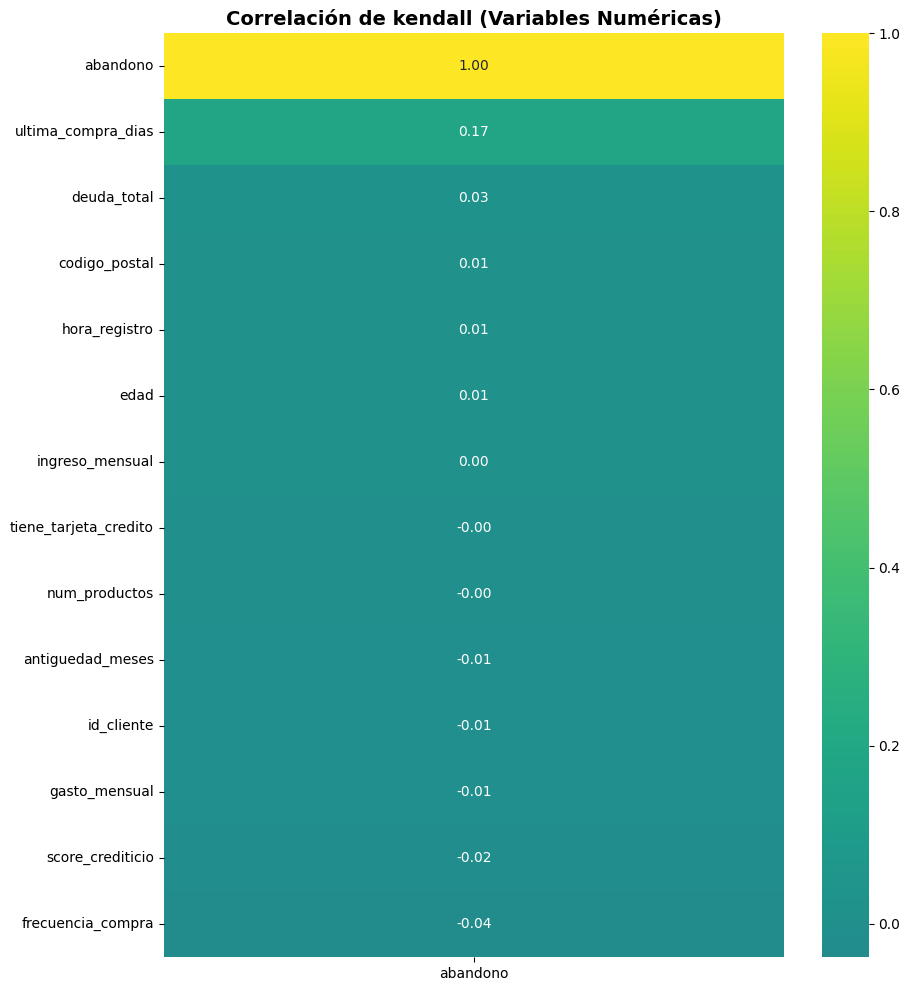

In [ ]:
def analizar_correlacion_robusta(df_sucio, x_metodo = 'kendall'):
    """
    ANÁLISIS DE CORRELACIÓN DE SPEARMAN ()

    Este bloque identifica las relaciones en el dataset 'df' ignorando
    automáticamente las columnas de texto que causarían errores de conversión.

   Usamos la correlacion de Spearman porque es ideal para
       detectar tendencias en datos que aún tienen valores negativos o
       extremadamente altos (outliers).

    """
    # 1. Calculamos la matriz de correlación de Spearman
    # Agregamos numeric_only=True para evitar el error con las fechas y textos
    matriz_spearman = df_sucio.corr(
        method=x_metodo,
        numeric_only=True
    )[['abandono']].sort_values(by='abandono', ascending=False)

    # 2. Configuración visual
    plt.figure(figsize=(10, 12))

    # 3. Generamos el Heatmap
    sns.heatmap(matriz_spearman, annot=True, cmap='viridis', fmt=".2f", center=0)

    plt.title(f"Correlación de {x_metodo} (Variables Numéricas)", fontsize=14, fontweight='bold')
    plt.show()

# Ejecutamos sobre el dataset original
analizar_correlacion_robusta(df, x_metodo = 'kendall')

* Los resultados de 0.01 o -0.01 indican que, en el estado actual de los datos, las variables se comportan de forma casi aleatoria respecto a nuestro target

* Los datos crudos, por sí solos, no tienen capacidad predictiva. Esto justifica obligatoriamente el uso de imputación y Winsorizing para "rescatar" la señal del negocio

* Este gráfico es nuestra "Línea de Base". Demuestra que sin el procesamiento que nosotros diseñamos en la máquina (Pipeline), la empresa no podría tomar ninguna decisión estratégica válida